- Run the GPR code from GPR2 on the full dataset to see how well it works.

In [13]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize

# Importing data
data = pd.read_csv(r"../../Data/misc/sol_sind_all.txt", sep='\s',skip_blank_lines=True, header = None, skiprows=1)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')


# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.5, valid_split=0.59):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

train_df, valid_df, test_df = split_df(data)
print(train_df.shape, valid_df.shape, test_df.shape)


def plot_predictions(trainingset, validset, results):
    fig, ax = plt.subplots(figsize=(20, 5))
    ax.plot(trainingset['year'], trainingset['sind'], color='blue', label='Training')
    ax.plot(validset['year'], validset['sind'], color='orange', label='Actual')
    results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(results_time, results['forecast'], color='green', label='Predictions')
    ax.fill_between(results_time, results['lower'], results['upper'], color='green', alpha=0.2, label='Uncertainties')
    plt.legend()
    plt.show()


train_mean = train_df["sind"].mean()
train_std  = train_df["sind"].std()


error_percent = 5
train_yerr = train_df['sind'] * error_percent / 100

(3174, 3) (3175, 3) (0, 3)


C:\Users\Joey\AppData\Local\Temp\ipykernel_31900\1353426718.py:10: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"../../Data/misc/sol_sind_all.txt", sep='\s',skip_blank_lines=True, header = None, skiprows=1)


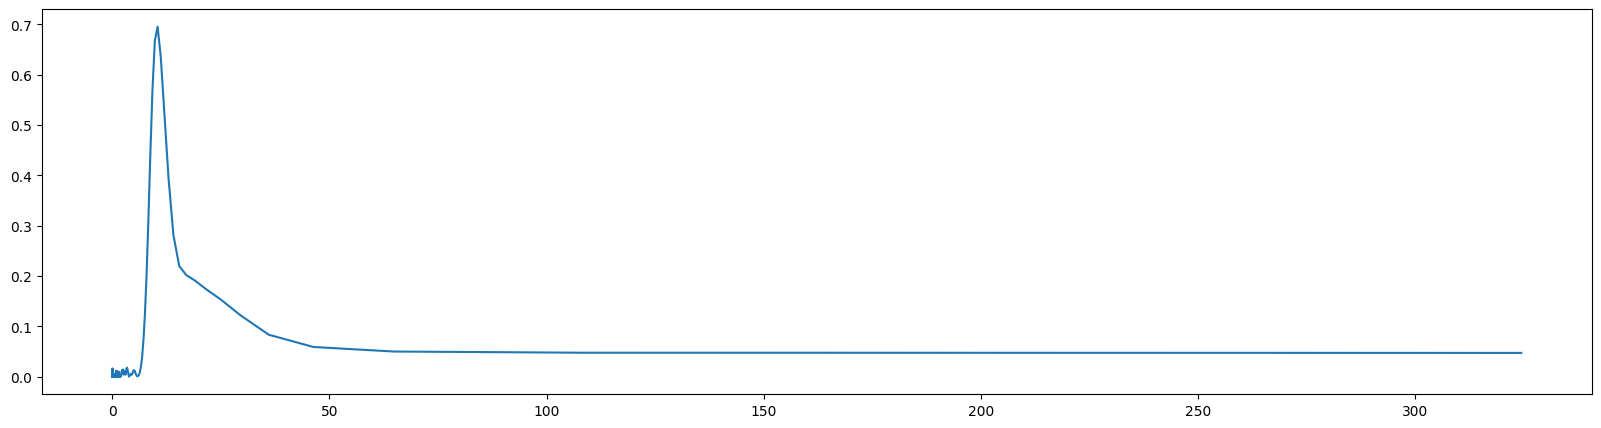

The best period is 10.463315890574522 years


In [14]:
# Lomb scargle 
# Lomb-Scargle finds periodic signals in unevnly sampled time series.
from astropy.timeseries import LombScargle

freq, power = LombScargle(train_df['year'], train_df['sind']).autopower()
# convert freq to period
period = 1/freq


# plot the thing
fig, ax = plt.subplots(1, figsize = (20,5))
ax.plot(period,power)
plt.show()

# print the best period
best_period = period[np.argmax(power)]
print(f"The best period is {best_period} years")


## SHO

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
SHOTerm:  sigma=0.00741 [0.0010,0.0328]  period=10.000 [10.0,12.0] yr  Q=0.5000 [0.500,10.000]


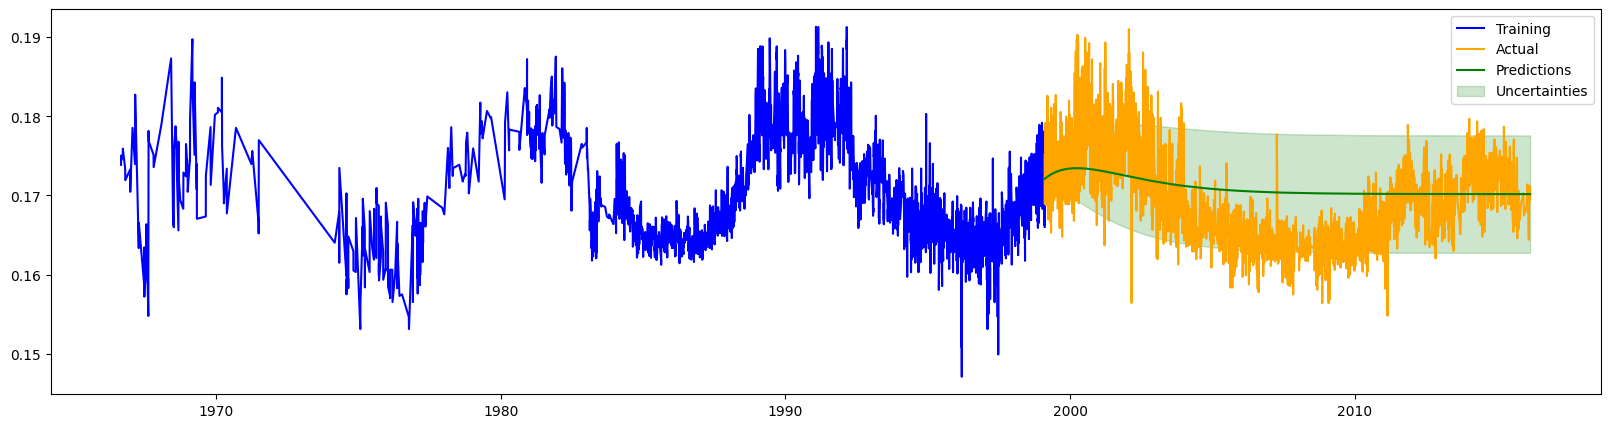

In [15]:
# Set params has to be different due to the new kernel
def set_params(log_params, gp):
    vals = np.exp(log_params)
    # gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4]) # have to replace the kernel otherwise the values don't change
    gp.kernel = terms.SHOTerm(sigma=vals[0], rho=vals[1], Q=vals[2])
    return gp

def NLL(log_params, gp, y):
    gp = set_params(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)


# quasi-periodic kernel: RotationTerm = two SHO terms
initial_params = {
    "sho_sigma": 0.003,  # set using total peak-to-peak drift/2
    "sho_rho": 11, # this is the period
    "sho_Q": 0.75 # natural frequency of the oscillator
                        # this lives in the overdamped threshold giving a smooth monotone
}

initial_guess = np.log([
    initial_params["sho_sigma"],
    initial_params["sho_rho"],
    initial_params["sho_Q"]
])

sigma_upper = 5 * train_std

bounds = [
    (np.log(0.001), np.log(sigma_upper)),   # sho_sigma
    (np.log(10.0),  np.log(12.0)),  # sho_rho: long-period trend >> 11 yr
    (np.log(0.5),  np.log(10)),   # sho_Q: force underdamped (>0.5)
]


kernel = terms.SHOTerm( # This looks like a decaying oscillation
                        sigma=initial_params['sho_sigma'],
                        Q=initial_params['sho_Q'], 
                        rho=initial_params['sho_rho']
)
gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=train_yerr)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
gp = set_params(gp_res.x, gp)
gp.recompute()

best_sh = np.exp(gp_res.x)
blo_sh = np.exp([b[0] for b in bounds])
bhi_sh = np.exp([b[1] for b in bounds])
print(gp_res.success, gp_res.message)
print(f"SHOTerm:  sigma={best_sh[0]:.5f} [{blo_sh[0]:.4f},{bhi_sh[0]:.4f}]  period={best_sh[1]:.3f} [{blo_sh[1]:.1f},{bhi_sh[1]:.1f}] yr  Q={best_sh[2]:.4f} [{blo_sh[2]:.3f},{bhi_sh[2]:.3f}]")


# now predict
t_pred = valid_df['year']
mu_sh, cov_sh = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
sigma_sh = np.sqrt(cov_sh)

# plot the lt results

results_sh = pd.DataFrame({
    'forecast' : mu_sh,
    'lower'    : mu_sh - sigma_sh,
    'upper'    : mu_sh + sigma_sh,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results_sh
                 )



## ROT

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
RotationTerm: sigma=0.00442 [0.0010,0.0197]  period=10.097 [9.50,12.00] yr  Q0=0.500 [0.50,10.00]  dQ=5.0000 [0.0010,5.00]  f=0.420 [0.010,0.990]


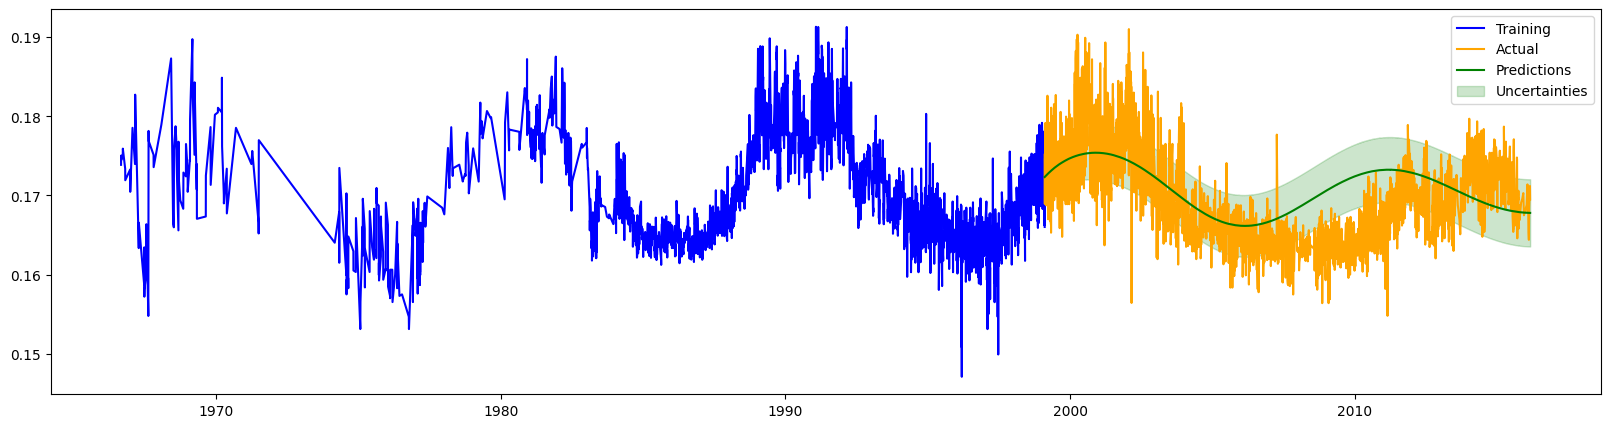

In [16]:
# Set params has to be different due to the new kernel
def set_params(log_params, gp):
    vals = np.exp(log_params)
    gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4]) # have to replace the kernel otherwise the values don't change
    return gp

def NLL(log_params, gp, y):
    gp = set_params(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)


# quasi-periodic kernel: RotationTerm = two SHO terms
initial_params = {
    "rot_sigma": train_std, # amplitude near observed variability
    "rot_period": 10.57, # solar cycle
    "rot_Q0": 1, # the quality factor of the decaying oscillation; how fast periods can change from one cycle to the next. q < 0.5 is overdamped > is underdamped
                            # choose 1 to be overdamped: plausible that the cycle is decently coherent in the longer term
    "rot_dQ": 0.01, # the difference in quality factors between the two oscillations in the rotation term. The dQ one has double the frequency
                            # this controls the phase coherence; large dq is more asymmetric
                            # we do not expect a strong P/2 signal as the assymetry is not too strong
    "rot_f": 0.1,  # the power fraction from the main term 
}

initial_guess = np.log([
    initial_params["rot_sigma"],
    initial_params["rot_period"],
    initial_params["rot_Q0"],
    initial_params["rot_dQ"],
    initial_params["rot_f"],
])

sigma_upper = 3 * train_std

bounds = [
    (np.log(0.001), np.log(sigma_upper)),   # rot_sigma: near data std
    (np.log(9.5),   np.log(12.0)),   # rot_period: solar cycle range
    (np.log(0.5),   np.log(10)),   # rot_Q0: force underdamped (>0.5)
    (np.log(0.001), np.log(5.0)),    # rot_dQ
    (np.log(0.01),  np.log(0.99)),   # rot_f: fraction in (0,1)
]


# Adding SHOTerm to the kernel
kernel = terms.RotationTerm( # Asymmetric decaying oscillation in lag-space
    sigma=initial_params['rot_sigma'],
    period=initial_params['rot_period'], 
    Q0=initial_params['rot_Q0'], 
    dQ=initial_params['rot_dQ'], 
    f=initial_params['rot_f'])

gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=train_yerr)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
gp = set_params(gp_res.x, gp)
gp.recompute()


best_rt = np.exp(gp_res.x)
blo_rt = np.exp([b[0] for b in bounds])
bhi_rt = np.exp([b[1] for b in bounds])
print(gp_res.success, gp_res.message)
print(f"RotationTerm: sigma={best_rt[0]:.5f} [{blo_rt[0]:.4f},{bhi_rt[0]:.4f}]  period={best_rt[1]:.3f} [{blo_rt[1]:.2f},{bhi_rt[1]:.2f}] yr  Q0={best_rt[2]:.3f} [{blo_rt[2]:.2f},{bhi_rt[2]:.2f}]  dQ={best_rt[3]:.4f} [{blo_rt[3]:.4f},{bhi_rt[3]:.2f}]  f={best_rt[4]:.3f} [{blo_rt[4]:.3f},{bhi_rt[4]:.3f}]")


# now predict
t_pred = valid_df['year']
mu_rt, cov_rt = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
sigma_rt = np.sqrt(cov_rt)

# plot the lt results

results_rt = pd.DataFrame({
    'forecast' : mu_rt,
    'lower'    : mu_rt - sigma_rt,
    'upper'    : mu_rt + sigma_rt,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results_rt
                 )



## SHO + ROT

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
RotationTerm: sigma=0.00444 [0.0010,0.0197]  period=10.098 [9.50,12.00] yr  Q0=0.500 [0.50,1.50]  dQ=5.0000 [0.0010,5.00]  f=0.416 [0.010,0.990]
SHOTerm:      sigma=0.00100 [0.0010,0.0197]  period=120.000 [70.0,120.0] yr  Q=0.6347 [0.500,3.000]


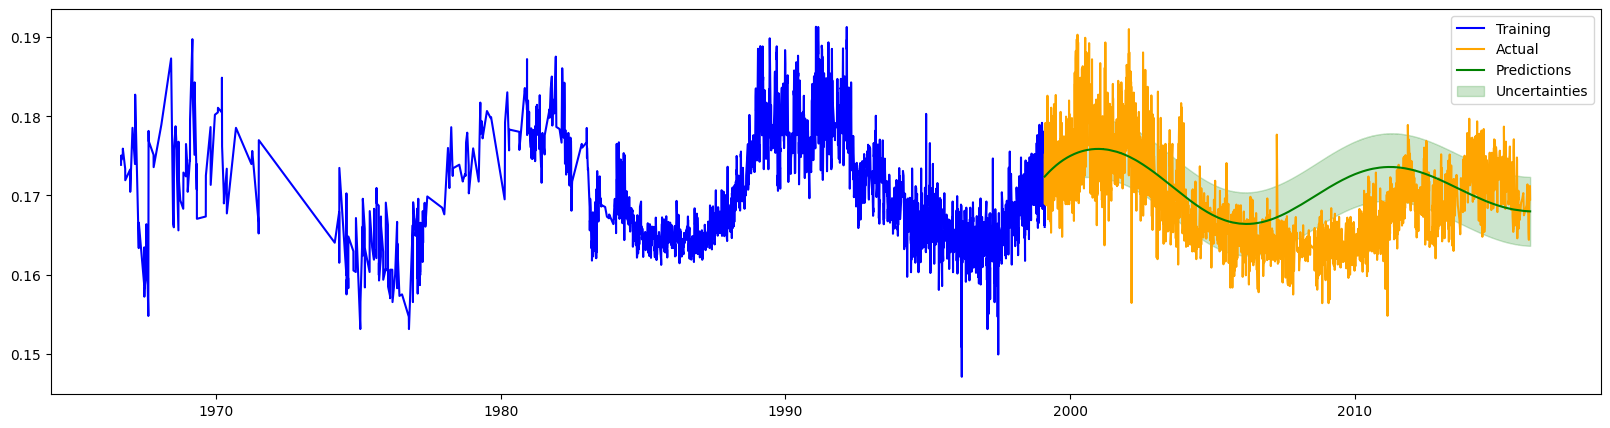

In [17]:
# Set params has to be different due to the new kernel
def set_params(log_params, gp):
    vals = np.exp(log_params)
    gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4]) # have to replace the kernel otherwise the values don't change
    gp.kernel += terms.SHOTerm(sigma=vals[5], rho=vals[6], Q=vals[7])
    
    return gp

def NLL(log_params, gp, y):
    gp = set_params(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)


# quasi-periodic kernel: RotationTerm = two SHO terms
initial_params = {
    "rot_sigma": train_std, # amplitude near observed variability
    "rot_period": 10.57, # solar cycle
    "rot_Q0": 2, # the quality factor of the decaying oscillation; how fast periods can change from one cycle to the next. q < 0.5 is overdamped > is underdamped
                            # choose 1 to be overdamped: plausible that the cycle is decently coherent in the longer term
    "rot_dQ": 0.5, # the difference in quality factors between the two oscillations in the rotation term. The dQ one has double the frequency
                            # this controls the phase coherence; large dq is more asymmetric
                            # we do not expect a strong P/2 signal as the assymetry is not too strong
    "rot_f": 0.5,  # the power fraction from the main term 
    "sho_sigma": 0.005,  # set using total peak-to-peak drift/2
    "sho_rho": 100, # this is the period
    "sho_Q": 0.2 # natural frequency of the oscillator
                        # this lives in the overdamped threshold giving a smooth monotone
}

initial_guess = np.log([
    initial_params["rot_sigma"],
    initial_params["rot_period"],
    initial_params["rot_Q0"],
    initial_params["rot_dQ"],
    initial_params["rot_f"],
    initial_params["sho_sigma"],
    initial_params["sho_rho"],
    initial_params["sho_Q"]
])

sigma_upper = 3 * train_std

bounds = [
    (np.log(0.001), np.log(sigma_upper)),   # rot_sigma: near data std
    (np.log(9.5),   np.log(12.0)),   # rot_period: solar cycle range
    (np.log(0.5),   np.log(1.5)),   # rot_Q0: force underdamped (>0.5)
    (np.log(0.001), np.log(5.0)),    # rot_dQ
    (np.log(0.01),  np.log(0.99)),   # rot_f: fraction in (0,1)
    (np.log(0.001), np.log(sigma_upper)),   # sho_sigma
    (np.log(70.0),  np.log(120.0)),  # sho_rho: Gleissberg cycle
    (np.log(0.5),  np.log(3.00)),   # sho_Q: force underdamped  as Gleissberg is an osc(>0.5)
]


# Adding SHOTerm to the kernel
kernel = terms.RotationTerm( # Asymmetric decaying oscillation in lag-space
    sigma=initial_params['rot_sigma'],
    period=initial_params['rot_period'], 
    Q0=initial_params['rot_Q0'], 
    dQ=initial_params['rot_dQ'], 
    f=initial_params['rot_f'])
kernel += terms.SHOTerm( # This looks like a decaying oscillation
                        sigma=initial_params['sho_sigma'],
                        Q=initial_params['sho_Q'], 
                        rho=initial_params['sho_rho']
)

gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=train_yerr)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
gp = set_params(gp_res.x, gp)
gp.recompute()

best_shrt = np.exp(gp_res.x)
blo_shrt = np.exp([b[0] for b in bounds])
bhi_shrt = np.exp([b[1] for b in bounds])
print(gp_res.success, gp_res.message)
print(f"RotationTerm: sigma={best_shrt[0]:.5f} [{blo_shrt[0]:.4f},{bhi_shrt[0]:.4f}]  period={best_shrt[1]:.3f} [{blo_shrt[1]:.2f},{bhi_shrt[1]:.2f}] yr  Q0={best_shrt[2]:.3f} [{blo_shrt[2]:.2f},{bhi_shrt[2]:.2f}]  dQ={best_shrt[3]:.4f} [{blo_shrt[3]:.4f},{bhi_shrt[3]:.2f}]  f={best_shrt[4]:.3f} [{blo_shrt[4]:.3f},{bhi_shrt[4]:.3f}]")
print(f"SHOTerm:      sigma={best_shrt[5]:.5f} [{blo_shrt[5]:.4f},{bhi_shrt[5]:.4f}]  period={best_shrt[6]:.3f} [{blo_shrt[6]:.1f},{bhi_shrt[6]:.1f}] yr  Q={best_shrt[7]:.4f} [{blo_shrt[7]:.3f},{bhi_shrt[7]:.3f}]")

# now predict
t_pred = valid_df['year']
mu_shrt, cov_shrt = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
sigma_shrt = np.sqrt(cov_shrt)

# plot the lt results

results_shrt = pd.DataFrame({
    'forecast' : mu_shrt,
    'lower'    : mu_shrt - sigma_shrt,
    'upper'    : mu_shrt + sigma_shrt,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results_shrt
                 )

1)
    - We're still collapsing the the boundaries.
        - RotationTerm: sigma=0.00443 [0.0010,0.0197]  period=10.083 [9.50,12.00] yr  Q0=0.500 [0.50,1.50]  dQ=5.0000 [0.0010,5.00]  f=0.411 [0.010,0.990]
        - SHOTerm:      sigma=0.00100 [0.0010,0.0197]  period=150.000 [50.0,150.0] yr  Q=0.1351 [0.010,0.490]
        - Perhaps the SHO Term is trying to turn itself off.
        - The rot_Q0, rot_dq, the sho_sigma, sho_period.
2) Tweaked bounds of SHO to better fit Gleissberg cycle.
    - Still non-functional
    - True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    - RotationTerm: sigma=0.00432 [0.0010,0.0199]  period=10.062 [9.50,12.00] yr  Q0=0.500 [0.50,1.50]  dQ=5.0000 [0.0010,5.00]  f=0.428 [0.010,0.990]
    - SHOTerm:      sigma=0.00100 [0.0010,0.0199]  period=120.000 [70.0,120.0] yr  Q=0.6761 [0.500,3.000]

## SHO + ROT Random

In [18]:
# Set params has to be different due to the new kernel
def set_params(log_params, gp):
    vals = np.exp(log_params)
    gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4]) # have to replace the kernel otherwise the values don't change
    gp.kernel += terms.SHOTerm(sigma=vals[5], rho=vals[6], Q=vals[7])
    
    return gp

def NLL(log_params, gp, y):
    gp = set_params(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

sigma_upper = 3 * train_std

bounds = [
    (np.log(0.001), np.log(sigma_upper)),   # rot_sigma: near data std
    (np.log(9.5),   np.log(12.0)),   # rot_period: solar cycle range
    (np.log(0.5),   np.log(1.5)),   # rot_Q0: force underdamped (>0.5)
    (np.log(0.001), np.log(5.0)),    # rot_dQ
    (np.log(0.01),  np.log(0.99)),   # rot_f: fraction in (0,1)
    (np.log(0.001), np.log(sigma_upper)),   # sho_sigma
    (np.log(70.0),  np.log(120.0)),  # sho_rho: Gleissberg cycle
    (np.log(0.5),  np.log(3.00)),   # sho_Q: force underdamped  as Gleissberg is an osc(>0.5)
]

n_starts = 10
results = []

for _ in range(n_starts):
    print(f"{_}/{n_starts - 1}")
    p0 = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    
    # Adding SHOTerm to the kernel
    kernel = terms.RotationTerm( # Asymmetric decaying oscillation in lag-space
        sigma=initial_params['rot_sigma'],
        period=initial_params['rot_period'], 
        Q0=initial_params['rot_Q0'], 
        dQ=initial_params['rot_dQ'], 
        f=initial_params['rot_f'])
    kernel += terms.SHOTerm( # This looks like a decaying oscillation
                            sigma=initial_params['sho_sigma'],
                            Q=initial_params['sho_Q'], 
                            rho=initial_params['sho_rho']
    )

    gp = celerite2.GaussianProcess(kernel, mean=train_mean)
    gp.compute(train_df['year'], yerr=train_yerr)

    gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
    gp = set_params(gp_res.x, gp)
    gp.recompute()

    # best_shrt = np.exp(gp_res.x)    
    results.append(gp_res) # to get values np.exp(gp.res.x)

results.sort(key=lambda r: r.fun) # sort by NLL



0/9
1/9
2/9
3/9
4/9
5/9
6/9
7/9
8/9
9/9


In [19]:
# Print the range of NLLs
NLL = []
for res in results:
    NLL.append(res.fun)
print(f"Mean is {np.mean(NLL)}")
print(f"Var is {np.var(NLL)}")

Mean is -11952.418129556503
Var is 3.308722450212111e-24


- They have all converged to the same NLL: same model...
- This implies that the model is our problem. 


In [20]:
# Describe the ranges of each variable for the best fitting model

best_shrt = np.exp(results[0].x)
blo_shrt = np.exp([b[0] for b in bounds])
bhi_shrt = np.exp([b[1] for b in bounds])
print(gp_res.success, gp_res.message)
print(f"RotationTerm: sigma={best_shrt[0]:.5f} [{blo_shrt[0]:.4f},{bhi_shrt[0]:.4f}]  period={best_shrt[1]:.3f} [{blo_shrt[1]:.2f},{bhi_shrt[1]:.2f}] yr  Q0={best_shrt[2]:.3f} [{blo_shrt[2]:.2f},{bhi_shrt[2]:.2f}]  dQ={best_shrt[3]:.4f} [{blo_shrt[3]:.4f},{bhi_shrt[3]:.2f}]  f={best_shrt[4]:.3f} [{blo_shrt[4]:.3f},{bhi_shrt[4]:.3f}]")
print(f"SHOTerm:      sigma={best_shrt[5]:.5f} [{blo_shrt[5]:.4f},{bhi_shrt[5]:.4f}]  period={best_shrt[6]:.3f} [{blo_shrt[6]:.1f},{bhi_shrt[6]:.1f}] yr  Q={best_shrt[7]:.4f} [{blo_shrt[7]:.3f},{bhi_shrt[7]:.3f}]")


True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
RotationTerm: sigma=0.00444 [0.0010,0.0197]  period=10.098 [9.50,12.00] yr  Q0=0.500 [0.50,1.50]  dQ=5.0000 [0.0010,5.00]  f=0.416 [0.010,0.990]
SHOTerm:      sigma=0.00100 [0.0010,0.0197]  period=120.000 [70.0,120.0] yr  Q=0.6347 [0.500,3.000]


In [21]:
# blo_shrt = np.exp([b[0] for b in bounds])
# bhi_shrt = np.exp([b[1] for b in bounds])
# print(gp_res.success, gp_res.message)
# print(f"RotationTerm: sigma={best_shrt[0]:.5f} [{blo_shrt[0]:.4f},{bhi_shrt[0]:.4f}]  period={best_shrt[1]:.3f} [{blo_shrt[1]:.2f},{bhi_shrt[1]:.2f}] yr  Q0={best_shrt[2]:.3f} [{blo_shrt[2]:.2f},{bhi_shrt[2]:.2f}]  dQ={best_shrt[3]:.4f} [{blo_shrt[3]:.4f},{bhi_shrt[3]:.2f}]  f={best_shrt[4]:.3f} [{blo_shrt[4]:.3f},{bhi_shrt[4]:.3f}]")
# print(f"SHOTerm:      sigma={best_shrt[5]:.5f} [{blo_shrt[5]:.4f},{bhi_shrt[5]:.4f}]  period={best_shrt[6]:.3f} [{blo_shrt[6]:.1f},{bhi_shrt[6]:.1f}] yr  Q={best_shrt[7]:.4f} [{blo_shrt[7]:.3f},{bhi_shrt[7]:.3f}]")

# # now predict
# t_pred = valid_df['year']
# mu_shrt, cov_shrt = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
# sigma_shrt = np.sqrt(cov_shrt)

# # plot the lt results

# results_shrt = pd.DataFrame({
#     'forecast' : mu_shrt,
#     'lower'    : mu_shrt - sigma_shrt,
#     'upper'    : mu_shrt + sigma_shrt,
# }, index=valid_df.index)

# plot_predictions(
#     trainingset=train_df,
#     validset=valid_df,
#     results=results_shrt
#                 )

## Spectral Mixture
- Our difficulty seems to come from the exact definition of the kernel itself.
- We can try letting the model learn this using a spectral mixture kernel.

# First, let's do a moving window on SHO+ROT

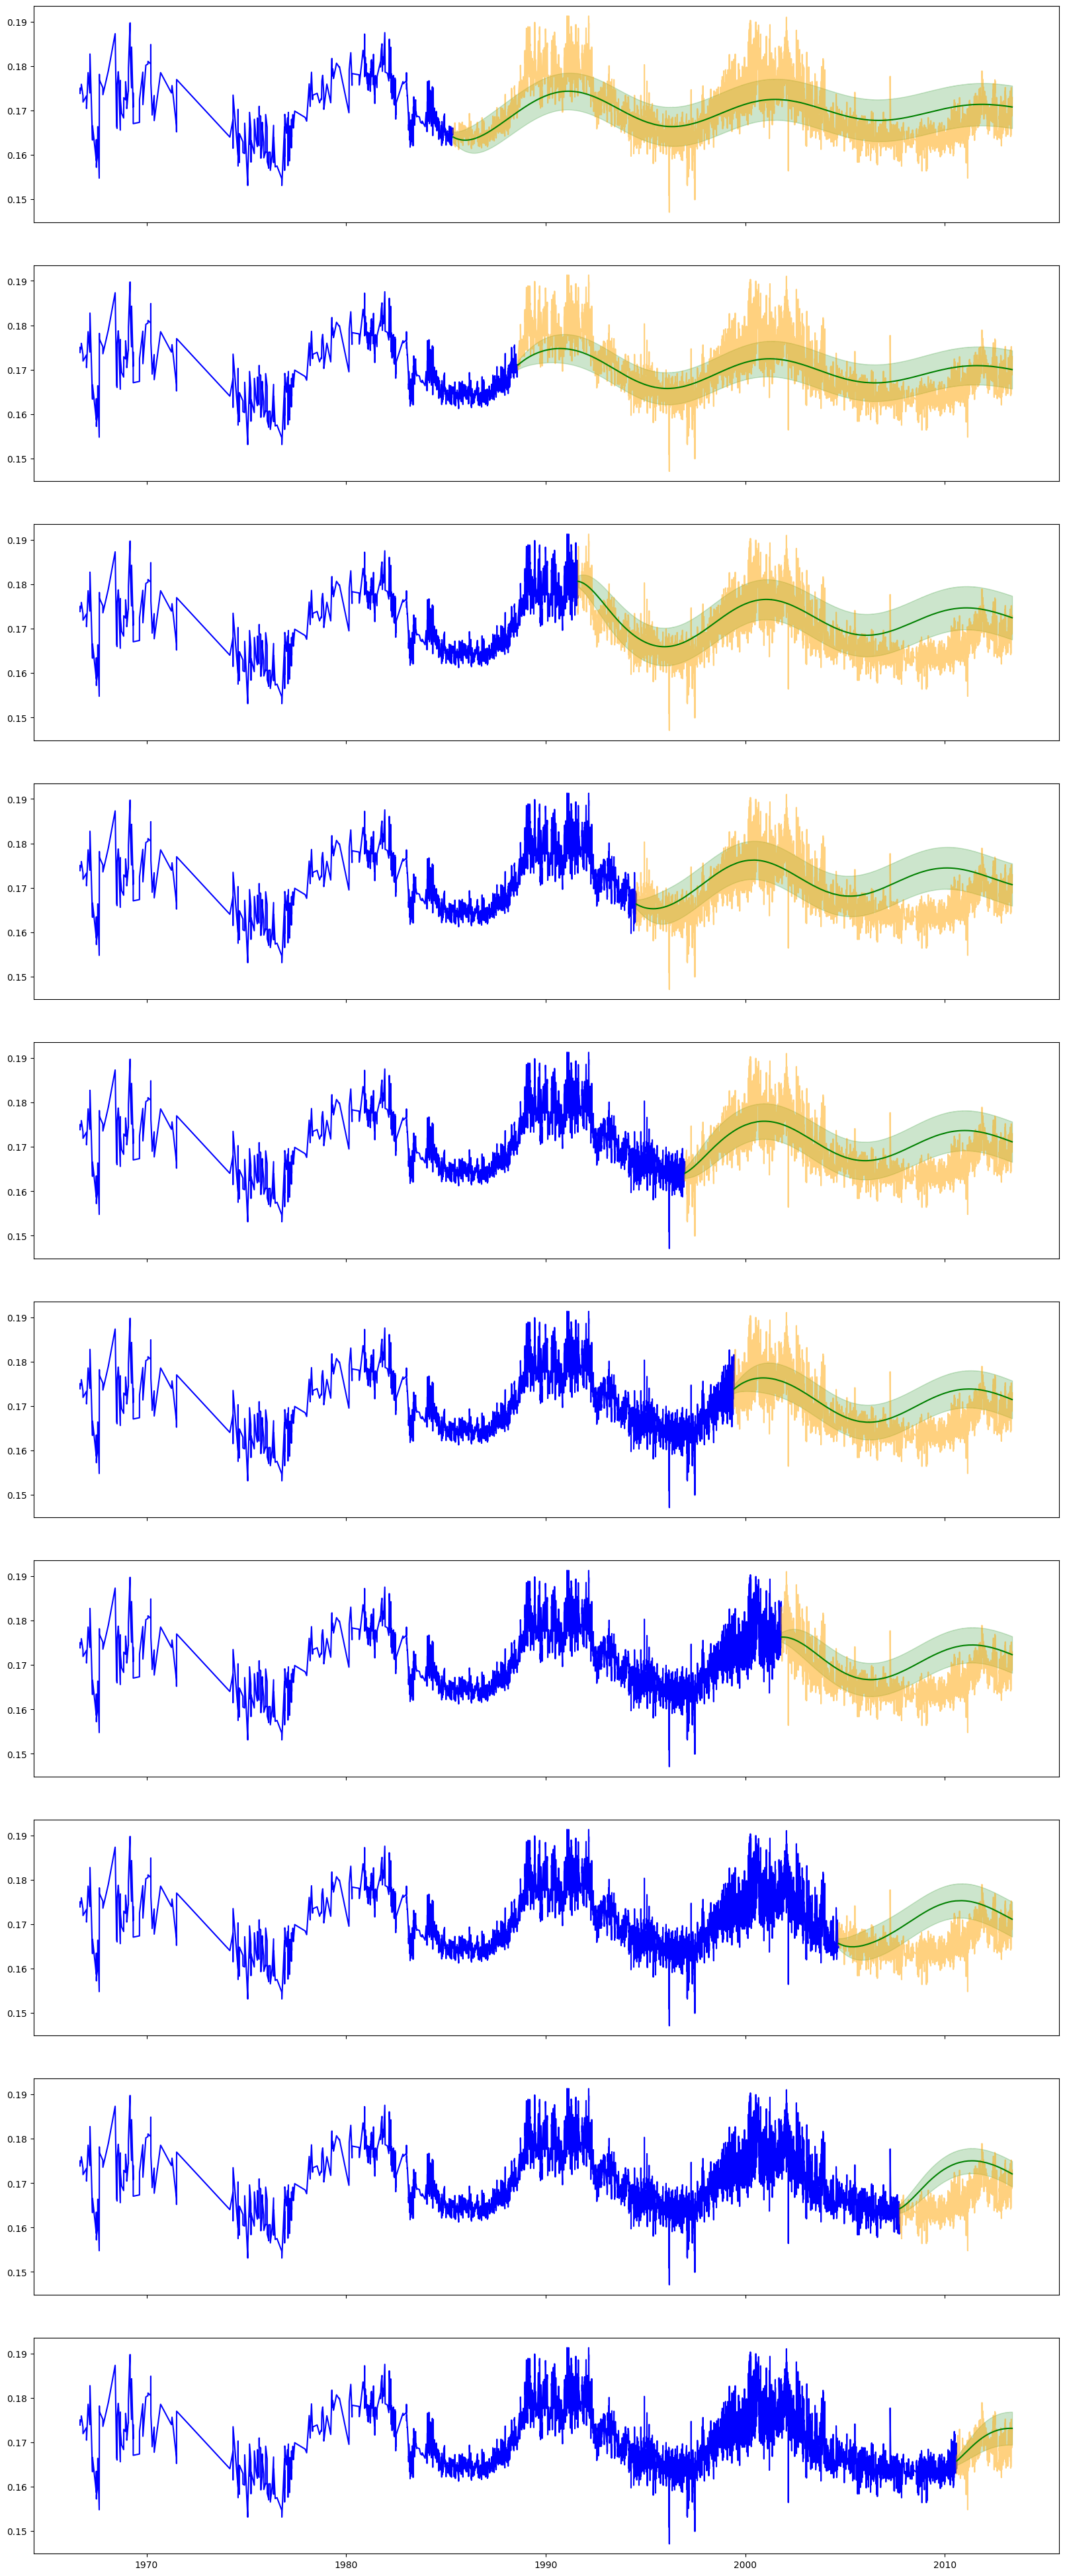

In [23]:
def _set_params_shrot(log_params, gp):
    vals = np.exp(log_params)
    gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4])
    gp.kernel += terms.SHOTerm(sigma=vals[5], rho=vals[6], Q=vals[7])
    return gp

def _nll_shrot(log_params, gp, y):
    gp = _set_params_shrot(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def train_test_model_shrot(train_split, valid_split, ax=None, verbose=False, data=data):
    train_df_w, valid_df_w, _ = split_df(data, train_split=train_split, valid_split=valid_split)
    train_mean_w = train_df_w["sind"].mean()
    train_std_w  = train_df_w["sind"].std()
    train_yerr_w = train_df_w['sind'] * 5 / 100

    sigma_upper = 3 * train_std_w

    initial_params = {
        "rot_sigma": train_std_w,
        "rot_period": 10.57,
        "rot_Q0": 2,
        "rot_dQ": 0.5,
        "rot_f": 0.5,
        "sho_sigma": 0.005,
        "sho_rho": 100,
        "sho_Q": 0.2
    }

    initial_guess = np.log([
        initial_params["rot_sigma"],
        initial_params["rot_period"],
        initial_params["rot_Q0"],
        initial_params["rot_dQ"],
        initial_params["rot_f"],
        initial_params["sho_sigma"],
        initial_params["sho_rho"],
        initial_params["sho_Q"]
    ])

    bounds = [
        (np.log(0.001), np.log(sigma_upper)),   # rot_sigma
        (np.log(9.5),   np.log(12.0)),           # rot_period
        (np.log(0.5),   np.log(1.5)),            # rot_Q0
        (np.log(0.001), np.log(5.0)),            # rot_dQ
        (np.log(0.01),  np.log(0.99)),           # rot_f
        (np.log(0.001), np.log(sigma_upper)),    # sho_sigma
        (np.log(70.0),  np.log(120.0)),          # sho_rho
        (np.log(0.5),   np.log(3.00)),           # sho_Q
    ]

    kernel = terms.RotationTerm(
        sigma=initial_params['rot_sigma'],
        period=initial_params['rot_period'],
        Q0=initial_params['rot_Q0'],
        dQ=initial_params['rot_dQ'],
        f=initial_params['rot_f'])
    kernel += terms.SHOTerm(
        sigma=initial_params['sho_sigma'],
        Q=initial_params['sho_Q'],
        rho=initial_params['sho_rho']
    )

    gp = celerite2.GaussianProcess(kernel, mean=train_mean_w)
    gp.compute(train_df_w['year'], yerr=train_yerr_w)

    gp_res = minimize(_nll_shrot, initial_guess, args=(gp, train_df_w["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
    gp = _set_params_shrot(gp_res.x, gp)
    gp.recompute()

    if verbose:
        best = np.exp(gp_res.x)
        print(gp_res.success, gp_res.message)
        print(f"RotationTerm: sigma={best[0]:.5f}  period={best[1]:.3f} yr  Q0={best[2]:.3f}  dQ={best[3]:.4f}  f={best[4]:.3f}")
        print(f"SHOTerm:      sigma={best[5]:.5f}  rho={best[6]:.3f} yr  Q={best[7]:.4f}")

    t_pred = valid_df_w['year']
    mu, cov = gp.predict(train_df_w['sind'], t=t_pred, return_var=True)
    pred_sigma = np.sqrt(cov)

    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 5))

    results_time = valid_df_w.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(train_df_w['year'], train_df_w['sind'], color='blue', label='Training')
    ax.plot(valid_df_w['year'], valid_df_w['sind'], color='orange', label='Actual', alpha=0.5)
    ax.plot(results_time, mu, color='green', label='Predictions')
    ax.fill_between(results_time, mu - pred_sigma, mu + pred_sigma, color='green', alpha=0.2, label='Uncertainties')

    return ax


def plot_moving_window_shrot(data=data, n_windows=10, train_low=0.1, train_high=0.9):
    fig, axes = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex=True, sharey=True)
    train_splits = np.linspace(train_low, train_high, n_windows)

    for idx, train_split in enumerate(train_splits):
        train_split_w = train_split * 0.95
        valid_split_w = 0.95 - train_split_w
        train_test_model_shrot(train_split=train_split_w, valid_split=valid_split_w, ax=axes[idx])

    plt.show()

plot_moving_window_shrot()